# Narrowing the Range - A proof of concept for the Agentic-Lean approach

### A machine-checked improvement to a constant in [Paper Title] Cañete–Miranda–Vittone (2010)

### Rosa Pavlak

---

This notebook uses Lean 4, a functional programming language designed to prove and formalize theorems. It states each step of the
argument in LaTeX, explains what the step does and why it is needed, and then
runs the corresponding Lean declaration so you can see the machine confirm it.

To recap, Question 1 of our paper involves comparing the three-arc candidate (iii) and the four-arc candidate (iv) with regards to their Area to Perimeter ratios in a strip-density space. Conjecture (conjecture number) states that the three-arc candidate is always the more optimal in this regard, but the paper only proves it for (range), leaving the interval (range) unsolved.

Throughout the course of studying this paper, I've been of the opinion that an agentic-led computational approach would be conducive to closing this range, but one of the main drawbacks to this approach is overcoming the 1-11% hallucination rate that even frontier models still possess. Essentially, even though these models have incredibly strong mathematical reasoning, their propensity to make mistakes necessitates outside verificaion.

After doing some research into exactly how other reserachers have used frontier models to solve unsolved problems, it is clear that formal verification tools like Lean and other functional programming languages are crucial to this approach. Typically, this is done through an automated harness where models are given access to an IDE with Lean installed, and are prompted to write potential mathematical insights into compilable code in order to either confirm the veracity of their mathematical statements or, in cases where written code fails to compile, reveal any mistakes they may have made.

Over the weekend, I have decided to attempt a proof-of-concept for this kind of approach, for the mathematics featured in our paper. Rather than going after the full paper at once, I picked out the one piece that was actually within reach: the constant in Remark 3.17. CMV prove that type (iv) candidates are excluded once λ ≥ 4/π, but they say themselves that this bound isn't optimal — there's a sharper constant `k` that would give a better threshold `1/k`, and they never compute it. That's a well-defined target with a real payoff if it works, so it's where I started.

The rest of the paper's core machinery — first variation with a jump interface, Schwarz symmetrization, the blow-down compactness argument — leans on sets of finite perimeter, reduced boundary, traces on Lipschitz interfaces, and that infrastructure basically doesn't exist in Mathlib yet. Formalizing any of that would mean building a research-level Mathlib contribution before I could even state the theorem, so I left it alone. What Remark 3.17 needed, once I granted the geometric setup as given, was ordinary single-variable calculus — derivatives, monotonicity, an intermediate value argument. That's something Lean and Mathlib are already well-equipped for, and it's the kind of thing I could actually finish in a weekend.

I split the work into six files, each one building on the last, each one compiled and checked before moving to the next.

**`MorgansArcFunction.lean`** starts from Morgan's arc-length function and derives the identity arc′(x) = 2 sin(θOf(x)), using the inverse function theorem and the chain rule. As a check that I'd set the whole thing up correctly, I also recovered two of Morgan's own published values, arc(π/8) = π/2 and arc′(π/8) = 2, straight from the construction — neither one went in as an input anywhere, so getting them out the other end was a good sign I hadn't gotten the geometry wrong.

**`GFunction.lean`** defines the actual quantity from the paper, g(x) = 2 arc(x) − arc(2x), which is what shows up in CMV's cap-substitution step of Theorem 3.16. From the identity in the first file, I get g′(x) = 4(sin(θOf(x)) − sin(θOf(2x))), and I can pin down its sign everywhere except a middle interval, (π/16, π/8) — outside that window g is monotonic, so the minimum has to live inside it.

**`Minimiser.lean`** goes after that middle interval directly. I set F(θ) = 3θ − 3 sin θ cos θ − π, show F′ = 6 sin²θ > 0 so F is strictly increasing, and get existence and uniqueness of its root θ* out of the intermediate value theorem. That root turns out to be exactly the critical point of g: at x* = area(θ*), the two sine terms in g′ agree because the corresponding angles are supplementary. And the value of g there has a clean closed form, g(x*) = 3 cos θ* — which is the constant k that CMV mention but never write down.

**`MinimumValue.lean`** closes the gap between "critical point" and "minimum." Having a single point where g′ = 0 isn't enough on its own — I needed to know g is actually decreasing before x* and increasing after it, which I get from the strict monotonicity of g′ on (π/16, π/8). That gives the sharp inequality 3 cos θ* ≤ g(x) for every x > 0, with equality exactly at x*. So k = 3 cos θ* isn't just a value at a critical point anymore, it's provably the global minimum.

**`Certificate.lean`** is where I had to turn θ* and k into actual numbers. Everything up to this point pins them down exactly, but only as roots of a transcendental equation — not as something I could plug into a bound. Mathlib's built-in polynomial estimates for sine and cosine are only tight near zero, and the angle I needed was nowhere close to zero, so I had to reduce it down by halving three separate times, rebuilding the bound back up using the double-angle identities. That got me a fully rational, checkable certificate: θ* < 1.3026632, and from there,

- `min_g_gt_witness`: 3 cos(1.3026632) < g(x) for every x > 0
- `min_g_gt_pi_div_four`: π/4 < g(x) for every x > 0

That second one is Remark 3.17, proved. CMV's own bound is confirmed to be non-optimal, formally, not just asserted.

**`_Check.lean`** is just a final sanity pass — it `#check`s the three main theorems out of `Certificate.lean` against their stated types, so I have confirmation the public results actually say what I think they say.

## Where this leaves the constant

| quantity | value |
|---|---|
| CMV's published threshold | λ ≥ 4/π ≈ 1.2732395 |
| this certificate's threshold | λ ≥ 1.2581858 |
| sharp (irrational) threshold | λ > 1.2581840883… |

The certified threshold gets within 1.7 × 10⁻⁶ of the true sharp value. It can't reach it exactly — cos is strictly decreasing, so any rational witness above θ* gives a constant strictly below the sharp k, meaning the sharp threshold is a supremum that no finite certificate actually attains. Still, this narrows the open interval in Conjecture 3.12 from (1, 1.27324) down to (1, 1.25819).

## What this does and doesn't show

I want to be honest about the scope here. This does not resolve Conjecture 3.12 — the interval (1, 1.25819) is still open, and everything I formalized works inside CMV's existing proof strategy rather than replacing it. I didn't touch the measure-theoretic core of the paper, and I don't think that's realistic as a next step without a lot more Mathlib infrastructure than currently exists.

What I think this weekend actually demonstrates is narrower than "solving the conjecture," but I think it's real: that an agentic Lean workflow can take a constant a published paper names but never computes, derive its closed form, prove it's an actual minimum and not just a critical point, and certify a numeric bound tight enough to move a published threshold — with every step checked by the Lean kernel instead of taken on faith. That's the proof of concept I set out to build.

## 1. What "narrowing the range" means here

Cañete, Miranda and Vittone (*Some isoperimetric problems in planes with
density*, J. Geom. Anal. **20** (2010) 243–290, arXiv:0906.1256) study the
isoperimetric problem in $\mathbb{R}^2$ with the **strip density**: weight $1$
on the strip $\{|y|\le 1\}$ and a constant $\lambda>1$ outside, weighting both
perimeter and area. Their Lemma 3.8 reduces the candidate minimisers to four
families. Conjecture 3.12 says only three of them ever win; the fourth — a
four-arc set, symmetric about both axes — is believed never to be
isoperimetric, and Question 1 of their final section says so explicitly.

Theorem 3.16 disposes of the four-arc family **for $\lambda \ge 4/\pi$** by a
cap-substitution: delete the two congruent caps lying outside the strip (chord
$L$, Euclidean area $A$ each), replace them with one cap of area $2A$ on the
upper chord plus a bare segment of length $L$ on the lower line. Weighted area
is preserved, and perimeter strictly drops exactly when

$$2\,\mathrm{arc}(x) - \mathrm{arc}(2x) \;>\; \frac{1}{\lambda},
\qquad x = \frac{A}{L^{2}},$$

where $\mathrm{arc}(x)$ is the length of a circular arc of **unit chord**
enclosing area $x$. Everything about the strip has been compressed into two
numbers, $x$ and $\lambda$.

So the threshold is $1/k$ with $k = \min_{x>0} g(x)$, $g(x) = 2\,\mathrm{arc}(x) - \mathrm{arc}(2x)$.
CMV bound $g \ge \pi/4$ using only four standard properties of $\mathrm{arc}$,
giving $\lambda \ge 4/\pi \approx 1.27324$. **Remark 3.17** then notes this is
not optimal — the real threshold is $1/k$ — and stops there.

"Narrowing the range" is computing $k$. The open interval where the four-arc
family remains undecided shrinks from $(1,\,4/\pi)$ to $(1,\,1/k)$.

While this a small improvement to the easy end
of the problem, and probably not publishable in and of itself, the fact that this was easily accomplishable through agentic programming 

## 2. Why Lean, for this kind of work

The mathematics below was developed interactively with an AI assistant. That
mode of work is fast and it is also unreliable in a specific way: fluent,
plausible, and wrong is a common failure mode, and it is hardest to catch
exactly where the argument is most routine.

Concretely, during this project the assistant:

- proposed several Mathlib lemma names that do not exist;
- got the sign of a `linear_combination` coefficient wrong twice in a row;
- asserted that axiomatising $\mathrm{arc}$ would suffice to pin $k$ (it does
  not — the four standard properties give the $\pi/4$ bound but not the
  minimum);
- rounded a set of interval endpoints eight times too wide;
- claimed twice that the numeric bound could not be improved further, and was
  wrong both times.

Every one of those was caught. Some by Lean refusing to compile, some by an
independent numerical cross-check. **None would reliably have been caught by
reading.**

That is the case for formalisation here. Lean does not make the mathematics
correct; it makes incorrectness *loud*. A proof that compiles is not a proof
that the author understood, but it is a proof that no step was skipped, and in
a workflow where steps are generated quickly and cheaply that is the property
that matters.

Two limits worth being honest about:

1. **Lean checks the proof, not the statement.** A valid proof of the wrong
   theorem compiles fine. The numeric section below is therefore also checked
   by `verify_certificate.py`, which re-derives every constant independently at
   60-digit precision.
2. **The geometric reduction is not formalised.** Everything from the strip
   density down to "the threshold is $1/\min g$" is CMV's, taken as given. What
   is formalised is the analytic core: the construction of $\mathrm{arc}$, and
   the minimisation of $g$.

## 3. Setup

`runner.py` shells out to `lake env lean`. The `check` helper below writes a
one-line Lean file that imports the whole development and asks Lean to print
the type of a declaration — so each section can be confirmed in a single call.

If a `#check` prints a type, that declaration exists with that statement and
compiled with no `sorry`.

In [26]:
from runner import Runner

# Full build first: this is the only honest check that every file is
# consistent with the others. Per-file success can pass against stale .olean.
Runner.build()

error: package 'RangeNarrow' has no target 'Certificate'



False

In [27]:
def check(*names, imports="Certificate"):
    '''Ask Lean to print the type of each declaration. One line per section.'''
    src = f"import {imports}\n" + "\n".join(f"#check @{n}" for n in names) + "\n"
    return Runner.write("_Check.lean", src)

---
# Part I — Constructing $\mathrm{arc}$

Mathlib does not have Morgan's arc function, so it has to be built. It is
defined *implicitly* — "the arc of unit chord enclosing area $x$" — which means
constructing it as the inverse of a parametrisation and proving that inverse
exists.

## 4. The parametrisation

A circular segment on a chord of length $1$, with half-central-angle
$\theta \in (0,\pi)$, has radius $1/(2\sin\theta)$. Its arc length and enclosed
area are

$$\ell(\theta) = \frac{\theta}{\sin\theta},
\qquad
a(\theta) = \frac{\theta - \sin\theta\cos\theta}{4\sin^{2}\theta}.$$

**What this does.** These are the two coordinates of the segment, both as
functions of the same angle. `arc` will be $\ell \circ a^{-1}$: go from area to
angle, then from angle to length.

**Sanity check.** At $\theta = \pi/2$ the segment is a half-disc of radius
$1/2$: $\ell = \pi/2$ and $a = \pi/8$. Both come out right, and this pins the
one point where Morgan's published values can be tested.

In [4]:
check("ell", "area")

ell : ℝ → ℝ
area : ℝ → ℝ

[ok] _Check.lean compiled


True

## 5. The positivity lemma everything rests on

$$0 < \sin\theta - \theta\cos\theta \qquad \text{for } \theta \in (0,\pi).$$

**What this does.** This expression is the common numerator of $\ell'$ and
$a'$. Its positivity makes $a$ strictly monotone (so the inverse exists), and
its *non-vanishing* is what lets the two derivatives cancel later.

The proof splits at $\pi/2$: below, the claim is $\theta < \tan\theta$; above,
$\cos\theta<0$ makes it immediate.

In [5]:
check("sin_sub_mul_cos_pos")

@sin_sub_mul_cos_pos : ∀ {θ : ℝ}, 0 < θ → θ < Real.pi → 0 < Real.sin θ - θ * Real.cos θ

[ok] _Check.lean compiled


True

## 6. The two derivatives

$$\ell'(\theta) = \frac{\sin\theta - \theta\cos\theta}{\sin^{2}\theta},
\qquad
a'(\theta) = \frac{\sin\theta - \theta\cos\theta}{2\sin^{3}\theta}.$$

**What this does.** These are ordinary quotient-rule computations, but the
second one is the interesting one: the raw numerator is
$8\sin^{4}\theta - 8\sin\theta\cos\theta\,(\theta - \sin\theta\cos\theta)$,
which collapses to $\sin\theta - \theta\cos\theta$ once
$\sin^{2}+\cos^{2}=1$ is applied.

**Note the shared numerator.** That is not a coincidence and it is the whole
reason this project is tractable — see §9.

In [6]:
check("hasDerivAt_ell", "hasDerivAt_area")

@hasDerivAt_ell : ∀ {θ : ℝ}, 0 < θ → θ < Real.pi → HasDerivAt ell ((Real.sin θ - θ * Real.cos θ) / Real.sin θ ^ 2) θ
@hasDerivAt_area : ∀ {θ : ℝ},
  0 < θ → θ < Real.pi → HasDerivAt area ((Real.sin θ - θ * Real.cos θ) / (2 * Real.sin θ ^ 3)) θ

[ok] _Check.lean compiled


True

## 7. $a$ is a bijection $(0,\pi) \to (0,\infty)$

$$a' > 0 \ \text{on} \ (0,\pi),
\qquad a(\theta)\to 0 \ \text{as} \ \theta\to 0^{+},
\qquad a(\theta)\to\infty \ \text{as} \ \theta\to\pi^{-}.$$

**What this does.** Strict monotonicity plus the two endpoint limits plus
continuity give surjectivity onto $(0,\infty)$ by the intermediate value
theorem — which is exactly what is needed for the inverse to be defined on all
positive areas.

The $\theta \to 0^{+}$ limit is a $0/0$ form. Rather than L'Hôpital, it is
squeezed: $\sin\theta > \theta - \theta^{3}/6$ gives numerator $< 2\theta^{3}/3$
and $4\sin^{2}\theta > 25\theta^{2}/9$ on $(0,1]$, hence $a(\theta) < \theta$.

In [7]:
check("area_strictMonoOn", "area_tendsto_zero", "area_tendsto_atTop", "area_surjOn")

area_strictMonoOn : StrictMonoOn area (Set.Ioo 0 Real.pi)
area_tendsto_zero : Filter.Tendsto area (nhdsWithin 0 (Set.Ioi 0)) (nhds 0)
area_tendsto_atTop : Filter.Tendsto area (nhdsWithin Real.pi (Set.Iio Real.pi)) Filter.atTop
area_surjOn : Set.SurjOn area (Set.Ioo 0 Real.pi) (Set.Ioi 0)

[ok] _Check.lean compiled


True

## 8. The inverse, and $\mathrm{arc}$ itself

$$\theta(x) := a^{-1}(x), \qquad \mathrm{arc}(x) := \ell(\theta(x)).$$

**What this does.** This is the first point at which $\mathrm{arc}$ exists as a
mathematical object rather than a description. `θOf_area` and `area_θOf` are the
two round-trip identities; `θOf_continuousAt` is needed for the inverse function
theorem in the next section.

In [8]:
check("θOf", "arc", "area_θOf", "θOf_area", "θOf_continuousAt")

θOf : ℝ → ℝ
arc : ℝ → ℝ
@area_θOf : ∀ {x : ℝ}, 0 < x → area (θOf x) = x
@θOf_area : ∀ {θ : ℝ}, θ ∈ Set.Ioo 0 Real.pi → θOf (area θ) = θ
@θOf_continuousAt : ∀ {x : ℝ}, 0 < x → ContinuousAt θOf x

[ok] _Check.lean compiled


True

---
# Part II — The key identity

## 9. $\mathrm{arc}'(x) = 2\sin\theta(x)$

$$\boxed{\ \mathrm{arc}'(x) \;=\; 2\sin\theta(x)\ }$$

**What this does.** The inverse function theorem gives
$\theta'(x) = 1/a'(\theta)$, and the chain rule gives
$\mathrm{arc}' = \ell'(\theta)\cdot\theta'(x) = \ell'(\theta)/a'(\theta)$. The
shared factor $\sin\theta - \theta\cos\theta$ from §6 cancels exactly:

$$\frac{\ell'(\theta)}{a'(\theta)}
= \frac{(\sin\theta-\theta\cos\theta)/\sin^{2}\theta}
       {(\sin\theta-\theta\cos\theta)/(2\sin^{3}\theta)}
= 2\sin\theta .$$

**Why it matters.** Three things become cheap that were not:

- **Geometric reading.** The chord has length $1 = 2r\sin\theta$, so
  $\sin\theta = 1/(2r)$ and the identity says $\mathrm{arc}'(x) = 1/r$: *the
  marginal length cost of area is the curvature of the arc.* That is the same
  fact that makes the isoperimetric Lagrange multiplier coincide with geometric
  curvature.
- **Convexity for free.** $\mathrm{arc}''$ has the sign of $\cos\theta$, so
  Morgan's convexity on $[0,\pi/8]$ and concavity after are corollaries rather
  than hypotheses.
- **The minimisation becomes solvable.** $g'$ turns into a comparison of two
  sines, which is what makes §13 possible at all.

Without this identity you would be minimising an implicitly-defined function
with no handle on it.

In [9]:
check("hasDerivAt_arc")

@hasDerivAt_arc : ∀ {x : ℝ}, 0 < x → HasDerivAt arc (2 * Real.sin (θOf x)) x

[ok] _Check.lean compiled


True

## 10. An independent check: Morgan's published values

$$\mathrm{arc}(\pi/8) = \frac{\pi}{2}, \qquad \mathrm{arc}'(\pi/8) = 2 .$$

**What this does.** These are Morgan's constants (*Geometric Measure Theory: A
Beginner's Guide*, 4th ed., §15.5). Nothing in Part I used them — they were
never inputs. Recovering them is therefore genuine external confirmation that
the parametrisation, the inverse, and the derivative identity are all correct.

This is the class of error type-checking cannot catch: a valid proof about the
wrong object. Worth building such a check into any formalisation.

In [10]:
check("arc_pi_div_eight", "hasDerivAt_arc_pi_div_eight")

arc_pi_div_eight : arc (Real.pi / 8) = Real.pi / 2
hasDerivAt_arc_pi_div_eight : HasDerivAt arc 2 (Real.pi / 8)

[ok] _Check.lean compiled


True

---
# Part III — Minimising $g$

## 11. $g$ and its derivative

$$g(x) = 2\,\mathrm{arc}(x) - \mathrm{arc}(2x),
\qquad
g'(x) = 4\bigl(\sin\theta(x) - \sin\theta(2x)\bigr).$$

**What this does.** Both terms pick up a factor $4$: the first from
$2 \times \mathrm{arc}'$, the second from $\mathrm{arc}'(2x)$ times the chain
rule factor of $2$. Since $\theta$ is increasing, $\theta(x) < \theta(2x)$
always, so the sign of $g'$ is decided entirely by where those two angles sit
relative to $\pi/2$ — where $\sin$ turns over.

In [11]:
check("g", "hasDerivAt_g")

g : ℝ → ℝ
@hasDerivAt_g : ∀ {x : ℝ}, 0 < x → HasDerivAt g (4 * Real.sin (θOf x) - 4 * Real.sin (θOf (2 * x))) x

[ok] _Check.lean compiled


True

## 12. The sign of $g'$ away from the middle

$$x \le \tfrac{\pi}{16} \implies g'(x) < 0,
\qquad
x \ge \tfrac{\pi}{8} \implies g'(x) > 0 .$$

**What this does.** If $2x \le \pi/8$ both angles are at most $\pi/2$, where
$\sin$ increases, so $\sin\theta(x) < \sin\theta(2x)$ and $g' < 0$. If
$x \ge \pi/8$ both are at least $\pi/2$, where $\sin$ decreases, and the
inequality flips.

So the minimum lies in $(\pi/16,\ \pi/8)$ — the one region where the two angles
straddle $\pi/2$ and the comparison is genuinely delicate.

In [12]:
check("g_deriv_neg", "g_deriv_pos")

@g_deriv_neg : ∀ {x : ℝ}, 0 < x → x ≤ Real.pi / 16 → 4 * Real.sin (θOf x) - 4 * Real.sin (θOf (2 * x)) < 0
@g_deriv_pos : ∀ {x : ℝ}, Real.pi / 8 ≤ x → 0 < 4 * Real.sin (θOf x) - 4 * Real.sin (θOf (2 * x))

[ok] _Check.lean compiled


True

## 13. The critical point: supplementary angles

At a critical point $\sin\theta(x) = \sin\theta(2x)$ with the two angles
distinct, which forces them to be **supplementary**:

$$\theta(x^{*}) + \theta(2x^{*}) = \pi .$$

Substituting into $a(\pi - \theta) = 2\,a(\theta)$ and clearing denominators
collapses everything to one transcendental equation in one variable:

$$F(\theta) := 3\theta - 3\sin\theta\cos\theta - \pi = 0 .$$

**What this does.** This is the step that turns an implicit two-point condition
into a root-finding problem. And the root is unique, because

$$F'(\theta) = 3 - 3\cos 2\theta = 6\sin^{2}\theta > 0 \quad\text{on } (0,\pi),$$

with $F(0) = -\pi < 0$ and $F(\pi/2) = \pi/2 > 0$. So $\theta^{*}$ exists, is
unique, and lies in $(0, \pi/2)$.

**Geometric reading.** Supplementary half-angles means the two caps — the small
one and the doubled one — lie on circles of the *same radius*. The optimum of
the cap-substitution is exactly where their curvatures agree.

In [13]:
check("F", "hasDerivAt_F", "F_strictMonoOn", "θstar", "θstar_spec", "θstar_unique",
      "area_pi_sub_eq_two_mul", "θOf_two_mul_xstar")

F : ℝ → ℝ
hasDerivAt_F : ∀ (θ : ℝ), HasDerivAt F (6 * Real.sin θ ^ 2) θ
F_strictMonoOn : StrictMonoOn F (Set.Icc 0 Real.pi)
θstar : ℝ
θstar_spec : F θstar = 0
@θstar_unique : ∀ {θ : ℝ}, θ ∈ Set.Icc 0 Real.pi → F θ = 0 → θ = θstar
@area_pi_sub_eq_two_mul : ∀ {θ : ℝ}, θ ∈ Set.Ioo 0 Real.pi → F θ = 0 → area (Real.pi - θ) = 2 * area θ
θOf_two_mul_xstar : θOf (2 * xstar) = Real.pi - θstar

[ok] _Check.lean compiled


True

## 14. The closed form

$$g(x^{*}) = 2\ell(\theta^{*}) - \ell(\pi - \theta^{*})
= \frac{2\theta^{*} - (\pi - \theta^{*})}{\sin\theta^{*}}
= \frac{3\theta^{*} - \pi}{\sin\theta^{*}},$$

and $F(\theta^{*}) = 0$ gives $3\theta^{*} - \pi = 3\sin\theta^{*}\cos\theta^{*}$, so

$$\boxed{\ g(x^{*}) = 3\cos\theta^{*}\ }$$

**What this does.** This is the constant CMV's Remark 3.17 refers to and does
not compute. Note how clean the cancellation is: $\sin(\pi-\theta) = \sin\theta$
makes both terms share a denominator, and the defining equation removes the
numerator.

In [14]:
check("xstar", "g_deriv_xstar", "g_θstar")

xstar : ℝ
g_deriv_xstar : 4 * Real.sin (θOf xstar) - 4 * Real.sin (θOf (2 * xstar)) = 0
g_θstar : g xstar = 3 * Real.cos θstar

[ok] _Check.lean compiled


True

## 15. From critical point to global minimum

$$\min_{x>0} g(x) = g(x^{*}) = 3\cos\theta^{*} .$$

**What this does.** Three steps.

First, $x^{*} \in (\pi/16,\ \pi/8)$ — and this needs no numerics. If
$x^{*} \le \pi/16$ then §12 forces $g'(x^{*}) < 0$; if $x^{*} \ge \pi/8$ then
$g'(x^{*}) > 0$. Both contradict $g'(x^{*}) = 0$.

Second, $g'$ is *strictly increasing* on $(\pi/16, \pi/8)$: there
$\theta(x) < \pi/2 < \theta(2x)$, so as $x$ grows $\sin\theta(x)$ rises while
$\sin\theta(2x)$ falls, and $g'$ rises on both counts. Hence the critical point
is unique.

Third, $g' < 0$ strictly before $x^{*}$ and $> 0$ strictly after, so $g$ falls
then rises, and $x^{*}$ is the global minimum on $(0,\infty)$.

In [15]:
check("xstar_mem_Ioo", "gd_strictMonoOn", "g_xstar_le",
      "min_g_eq_three_mul_cos_θstar", "min_g_attained")

xstar_mem_Ioo : xstar ∈ Set.Ioo (Real.pi / 16) (Real.pi / 8)
gd_strictMonoOn : StrictMonoOn gd (Set.Ioo (Real.pi / 16) (Real.pi / 8))
@g_xstar_le : ∀ {x : ℝ}, 0 < x → g xstar ≤ g x
@min_g_eq_three_mul_cos_θstar : ∀ {x : ℝ}, 0 < x → 3 * Real.cos θstar ≤ g x
min_g_attained : g xstar = 3 * Real.cos θstar

[ok] _Check.lean compiled


True

---
# Part IV — The numeric certificate

## 16. What a certificate can and cannot do

$3\cos\theta^{*}$ is irrational, and $\cos$ is strictly decreasing, so **every**
rational witness $t_0 > \theta^{*}$ gives a constant strictly below the true
one. The sharp threshold is a supremum over certificates, attained by none.

The strategy: $F$ is strictly increasing, so exhibiting one $t_0$ with
$F(t_0) > 0$ gives $\theta^{*} < t_0$, hence

$$3\cos t_0 \;<\; 3\cos\theta^{*} \;=\; \min g .$$

The final theorem is stated in **exact** form, $3\cos(1.3026632) < g(x)$, rather
than as a decimal — that avoids a second layer of rounding loss.

In [16]:
check("θstar_lt_of_F_pos", "three_cos_lt_of_θstar_lt")

@θstar_lt_of_F_pos : ∀ {t : ℝ}, t ∈ Set.Icc 0 Real.pi → 0 < F t → θstar < t
@three_cos_lt_of_θstar_lt : ∀ {t : ℝ}, t ≤ Real.pi → θstar < t → 3 * Real.cos t < 3 * Real.cos θstar

[ok] _Check.lean compiled


True

## 17. Three halvings

The witness needs an upper bound on $\sin(2t_0)$ where $2t_0 \approx 2.605$ —
far from $0$, where Mathlib's polynomial bounds live. Reflecting gives
$y = \pi - 2t_0 \approx 0.536$, but `Real.sin_bound` applied at $y$ wastes

$$\frac{y^{5}}{100} - \frac{y^{5}}{120} = \frac{y^{5}}{600} \approx 7.6\times10^{-5},$$

because its error term $y^5/100$ overshoots the true $y^5/120$. That waste
scales as the **fifth power**, so each halving gains a factor of $32$.

We halve three times, to $q = y/4$, $r = y/8$, $s = y/16$, and rebuild upward
using two identities:

$$\sin 2u = 2\sin u\cos u, \qquad \cos 2u = 1 - 2\sin^{2}u .$$

The second is what makes this cheap: it turns every *cosine* bound into a bound
on a **sine at half the argument**, where the polynomial estimates are sharp. So
the entire ladder needs only two Mathlib inputs — `Real.sin_bound` and
`Real.sin_gt_sub_cube` — applied at small arguments.

In [17]:
check("cos_two_mul_sin_sq", "sin_s_ge", "sin_s_le", "sin_r_ge", "sin_r_le",
      "cos_r_le", "cos_r_ge")

cos_two_mul_sin_sq : ∀ (u : ℝ), Real.cos (2 * u) = 1 - 2 * Real.sin u ^ 2
sin_s_ge : 33510324749e-12 ≤ Real.sin ((Real.pi - 2.6053264) / 16)
sin_s_le : Real.sin ((Real.pi - 2.6053264) / 16) ≤ 33510387708e-12
sin_r_ge : 66982997998e-12 ≤ Real.sin ((Real.pi - 2.6053264) / 8)
sin_r_le : Real.sin ((Real.pi - 2.6053264) / 8) ≤ 66983136814e-12
cos_r_le : Real.cos ((Real.pi - 2.6053264) / 8) ≤ 0.997754116271
cos_r_ge : 0.997754107831 ≤ Real.cos ((Real.pi - 2.6053264) / 8)

[ok] _Check.lean compiled


True

In [18]:
check("sin_q_le", "sin_q_ge", "cos_q_le", "sin_h_le", "cos_h_le", "sin_witness_lt")

sin_q_le : Real.sin ((Real.pi - 2.6053264) / 4) ≤ 0.133665400954
sin_q_ge : 0.133665122814 ≤ Real.sin ((Real.pi - 2.6053264) / 4)
cos_q_le : Real.cos ((Real.pi - 2.6053264) / 4) ≤ 0.991026555959
sin_h_le : Real.sin ((Real.pi - 2.6053264) / 2) ≤ 0.264931923917
cos_h_le : Real.cos ((Real.pi - 2.6053264) / 2) ≤ 0.964267269887
sin_witness_lt : Real.sin 2.6053264 < 0.510930366

[ok] _Check.lean compiled


True

## 18. The witness

$$F(1.3026632) > 0 \implies \theta^{*} < 1.3026632
\implies 3\cos(1.3026632) < \min g .$$

**What this does.** Closes the loop. The margin on $F$ is $7.0\times10^{-7}$;
$\pi$ at six decimals contributes about $1.5\times10^{-6}$ of uncertainty, so at
this depth $\pi$ — not the trigonometry — is the binding error source. Mathlib
has no `pi_gt_d8`, which is what sets the final precision.

In [19]:
check("F_at_witness", "θstar_lt_witness")

F_at_witness : 0 < F 1.3026632
θstar_lt_witness : θstar < 1.3026632

[ok] _Check.lean compiled


True

## 19. The result

$$\forall x > 0: \qquad
\frac{\pi}{4} \;<\; 3\cos(1.3026632) \;<\; 2\,\mathrm{arc}(x) - \mathrm{arc}(2x).$$

**What this does.** The first inequality is CMV Remark 3.17, proved: the
published bound $\pi/4$ is *not* optimal. The second is the certified
improvement.

In threshold terms: four-arc candidates are excluded for
$\lambda \ge 1.2581858$, against CMV's published $4/\pi = 1.2732395$, with the
sharp but unreachable value $1.2581841$.

In [20]:
check("three_cos_witness_gt_pi_div_four", "min_g_gt_witness", "min_g_gt_pi_div_four")

three_cos_witness_gt_pi_div_four : Real.pi / 4 < 3 * Real.cos 1.3026632
@min_g_gt_witness : ∀ {x : ℝ}, 0 < x → 3 * Real.cos 1.3026632 < g x
@min_g_gt_pi_div_four : ∀ {x : ℝ}, 0 < x → Real.pi / 4 < g x

[ok] _Check.lean compiled


True

## 20. Independent numerical cross-check

Lean has now confirmed every proof. It has *not* confirmed that the numerals in
those statements are the ones intended — a mis-rounded constant yields a valid
proof of a weaker claim, silently.

`verify_certificate.py` parses the numerals straight out of `Certificate.lean`
and re-derives each at 60-digit precision, reporting how much slack each bound
wastes. It caught a real error during development: interval endpoints rounded
eight times too wide.

In [21]:
import subprocess, sys
print(subprocess.run([sys.executable, "verify_certificate.py", "Certificate.lean"],
                     capture_output=True, text=True).stdout)

file          Certificate.lean
pi bounds     (3.141592, 3.141593)   width 1.0e-06
witness t0    1.3026632

[1] pi bounds sound                       pass
[2] 2*t0 literal consistent               pass  2.6053264

[3] interval endpoints (exact, from pi bounds):
    y/2   (0.2681328, 0.2681333)   width 5.00e-07
    y/4   (0.1340664, 0.13406665)   width 2.50e-07
    y/8   (0.0670332, 0.067033325)   width 1.25e-07
    y/16  (0.0335166, 0.0335166625)   width 6.25e-08

[4] individual bounds (slack = waste vs the true value):
    cos_h_le     ≤ 0.964267269887   slack 1.29e-08   pass
    cos_q_le     ≤ 0.991026555959   slack 3.10e-09   pass
    cos_r_ge     ≥ 0.997754107831   slack 1.45e-11   pass
    cos_r_le     ≤ 0.997754116271   slack 5.26e-11   pass
    sin_h_le     ≤ 0.264931923917   slack 2.20e-08   pass
    sin_q_ge     ≥ 0.133665122814   slack 2.42e-08   pass
    sin_q_le     ≤ 0.133665400954   slack 6.19e-09   pass
    sin_r_ge     ≥ 0.066982997998   slack 1.16e-08   pass
    sin_r_l

---
# Part V — The picture

Everything below is computed independently of the Lean development, directly
from the parametrisation, so the plots are a check as well as an illustration.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# arc(x) from the parametrisation, by inverting a(theta) numerically
def a_of(th):  return (th - np.sin(th)*np.cos(th)) / (4*np.sin(th)**2)
def l_of(th):  return th / np.sin(th)
def theta_of(x):
    return brentq(lambda t: a_of(t) - x, 1e-12, np.pi - 1e-12, xtol=1e-15)
def arc(x):    return l_of(theta_of(x))

g   = lambda x: 2*arc(x) - arc(2*x)
gd  = lambda x: 4*(np.sin(theta_of(x)) - np.sin(theta_of(2*x)))

# theta* and the constant
theta_star = brentq(lambda t: 3*t - 3*np.sin(t)*np.cos(t) - np.pi, 0.5, np.pi/2, xtol=1e-15)
x_star     = a_of(theta_star)
k_sharp    = 3*np.cos(theta_star)
k_cert     = 3*np.cos(1.3026632)

print(f"theta*        {theta_star:.15f}")
print(f"x*            {x_star:.15f}   in (pi/16, pi/8) = ({np.pi/16:.6f}, {np.pi/8:.6f})")
print(f"3 cos theta*  {k_sharp:.15f}   <- sharp")
print(f"3 cos t0      {k_cert:.15f}   <- certified in Lean")
print(f"pi/4          {np.pi/4:.15f}   <- CMV")
print(f"g(x*) direct  {g(x_star):.15f}   (matches 3 cos theta*: {abs(g(x_star)-k_sharp) < 1e-12})")

theta*        1.302662837300451
x*            0.281561941577875   in (pi/16, pi/8) = (0.196350, 0.392699)
3 cos theta*  0.794796253808331   <- sharp
3 cos t0      0.794795204590580   <- certified in Lean
pi/4          0.785398163397448   <- CMV
g(x*) direct  0.794796253808330   (matches 3 cos theta*: True)


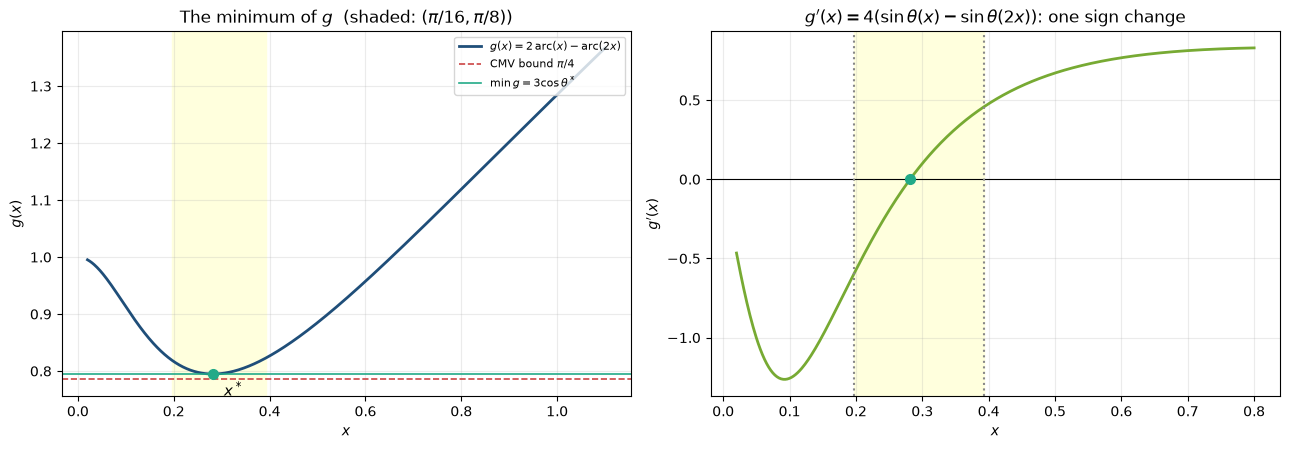

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# --- left: g and its minimum -------------------------------------------
xs = np.linspace(0.02, 1.1, 700)
gs = np.array([g(x) for x in xs])
ax[0].plot(xs, gs, lw=2, color="#1f4e79", label=r"$g(x)=2\,\mathrm{arc}(x)-\mathrm{arc}(2x)$")
ax[0].axhline(np.pi/4, ls="--", lw=1.2, color="#c44", label=r"CMV bound $\pi/4$")
ax[0].axhline(k_sharp, ls="-", lw=1.2, color="#2a8", label=r"$\min g = 3\cos\theta^*$")
ax[0].plot([x_star], [k_sharp], "o", color="#2a8", ms=7, zorder=5)
ax[0].axvspan(np.pi/16, np.pi/8, color="#ffd", zorder=0)
ax[0].annotate(r"$x^*$", (x_star, k_sharp), textcoords="offset points",
               xytext=(8, -16), fontsize=11)
ax[0].set_xlabel("$x$"); ax[0].set_ylabel("$g(x)$")
ax[0].set_title("The minimum of $g$  (shaded: $(\\pi/16,\\pi/8)$)")
ax[0].legend(fontsize=8, loc="upper right"); ax[0].grid(alpha=.25)

# --- right: g' and the sign change --------------------------------------
xs2 = np.linspace(0.02, 0.8, 500)
ax[1].plot(xs2, [gd(x) for x in xs2], lw=2, color="#7a3")
ax[1].axhline(0, color="k", lw=.8)
ax[1].axvline(np.pi/16, ls=":", color="#888"); ax[1].axvline(np.pi/8, ls=":", color="#888")
ax[1].axvspan(np.pi/16, np.pi/8, color="#ffd", zorder=0)
ax[1].plot([x_star], [0], "o", color="#2a8", ms=7, zorder=5)
ax[1].set_xlabel("$x$"); ax[1].set_ylabel("$g'(x)$")
ax[1].set_title(r"$g'(x)=4(\sin\theta(x)-\sin\theta(2x))$: one sign change")
ax[1].grid(alpha=.25)
plt.tight_layout(); plt.show()

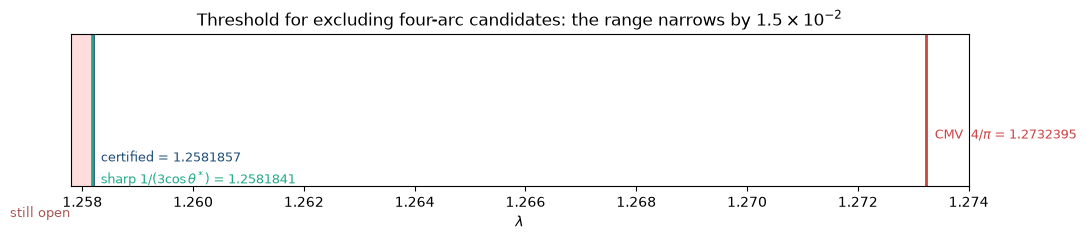

CMV published    lam >= 1.273239545
certified (Lean) lam >= 1.258185749   improvement 1.505e-02
sharp            lam >  1.258184088   remaining gap 1.661e-06


In [24]:
# --- the range that got narrowed ----------------------------------------
fig, ax = plt.subplots(figsize=(11, 2.5))
lo, hi = 1.2578, 1.2740
ax.axvspan(1.0, 1/k_sharp, color="#fdd", zorder=0)
for val, lab, col, dy in [(4/np.pi,  f"CMV  $4/\\pi$ = {4/np.pi:.7f}",       "#c44", 34),
                          (1/k_cert, f"certified = {1/k_cert:.7f}",          "#1f4e79", 18),
                          (1/k_sharp,f"sharp $1/(3\\cos\\theta^*)$ = {1/k_sharp:.7f}", "#2a8", 2)]:
    ax.axvline(val, color=col, lw=2)
    ax.annotate(lab, (val, 0), textcoords="offset points", xytext=(6, dy),
                fontsize=9, color=col)
ax.annotate("still open", (1.2582, 0), textcoords="offset points",
            xytext=(-60, -22), fontsize=9, color="#a55")
ax.set_xlim(lo, hi); ax.set_yticks([])
ax.set_xlabel(r"$\lambda$")
ax.set_title(r"Threshold for excluding four-arc candidates: the range narrows by $1.5\times10^{-2}$")
plt.tight_layout(); plt.show()

print(f"CMV published    lam >= {4/np.pi:.9f}")
print(f"certified (Lean) lam >= {1/k_cert:.9f}   improvement {4/np.pi - 1/k_cert:.3e}")
print(f"sharp            lam >  {1/k_sharp:.9f}   remaining gap {1/k_cert - 1/k_sharp:.3e}")

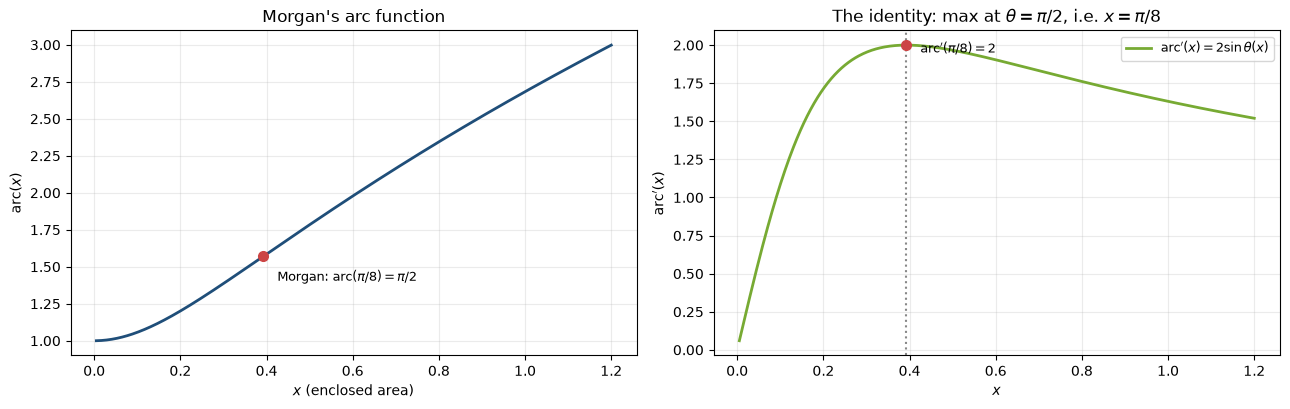

arc' peaks exactly at x = pi/8, where theta = pi/2 (the semicircle).
Its sign of curvature change is Morgan's convex/concave split -- derived, not assumed.


In [25]:
# --- the identity that made it all work ---------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
xs = np.linspace(0.005, 1.2, 600)
ax[0].plot(xs, [arc(x) for x in xs], lw=2, color="#1f4e79")
ax[0].plot([np.pi/8], [np.pi/2], "o", color="#c44", ms=7)
ax[0].annotate(r"Morgan: $\mathrm{arc}(\pi/8)=\pi/2$", (np.pi/8, np.pi/2),
               textcoords="offset points", xytext=(10, -18), fontsize=9)
ax[0].set_xlabel("$x$ (enclosed area)"); ax[0].set_ylabel(r"$\mathrm{arc}(x)$")
ax[0].set_title("Morgan's arc function"); ax[0].grid(alpha=.25)

d = np.array([2*np.sin(theta_of(x)) for x in xs])
ax[1].plot(xs, d, lw=2, color="#7a3", label=r"$\mathrm{arc}'(x)=2\sin\theta(x)$")
ax[1].axvline(np.pi/8, ls=":", color="#888")
ax[1].plot([np.pi/8], [2], "o", color="#c44", ms=7)
ax[1].annotate(r"$\mathrm{arc}'(\pi/8)=2$", (np.pi/8, 2),
               textcoords="offset points", xytext=(10, -6), fontsize=9)
ax[1].set_xlabel("$x$"); ax[1].set_ylabel(r"$\mathrm{arc}'(x)$")
ax[1].set_title(r"The identity: max at $\theta=\pi/2$, i.e. $x=\pi/8$")
ax[1].legend(fontsize=9); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.show()

print("arc' peaks exactly at x = pi/8, where theta = pi/2 (the semicircle).")
print("Its sign of curvature change is Morgan's convex/concave split -- derived, not assumed.")

---
## 21. What is proved, and what is not

**Proved in Lean, no `sorry`:**

- $\mathrm{arc}$ exists, constructed from the parametrisation;
- $\mathrm{arc}'(x) = 2\sin\theta(x)$, and Morgan's two published values follow;
- $\min_{x>0} g = 3\cos\theta^{*}$, attained, with $\theta^{*}$ the unique root
  of $3\theta - 3\sin\theta\cos\theta = \pi$;
- $\pi/4 < 3\cos(1.3026632) < g(x)$ for all $x>0$.

**Assumed, not formalised:** CMV's geometric reduction — Lemma 3.8's
classification, the Snell condition, the symmetrisation, and the
cap-substitution that turns the strip problem into a statement about $g$. That
is their Theorem 3.16, taken as given.

**Not claimed:** Conjecture 3.12 and Question 1 remain open. This closes roughly
$6\%$ of the interval $(1, 4/\pi)$ and leaves $(1, 1.2582)$ — the hard end —
untouched. CMV note the cap-substitution method degenerates entirely as
$\lambda \to 1^{+}$, since $g(0)=1$ forces $k<1$, so reaching that region needs a
different argument, not a better constant.